# Taller de Inteligencia Artificial
## Análisis de datos de NO₂ y modelado mediante regresión lineal

**Tema:** Análisis de la calidad del aire mediante técnicas de regresión  
**Lugar de estudio:** Phoenix-Mesa-Scottsdale, Arizona  
**Periodo analizado:** Año 2022  
**Fuente de datos:** United States Environmental Protection Agency (EPA)

---

### Introducción

El presente trabajo analiza registros diarios de **dióxido de nitrógeno (NO₂)** correspondientes al año 2022 en el área metropolitana de Phoenix-Mesa-Scottsdale, Arizona.

El análisis comprende una etapa exploratoria de los datos, la selección de variables relevantes y la construcción de un modelo de **regresión lineal** orientado a estimar el valor diario del **Air Quality Index (AQI)**.

### Objetivo

Analizar la relación entre la concentración máxima diaria de NO₂ y el valor diario del AQI, considerando además variables asociadas con la ubicación del sitio de monitoreo y el periodo del año.


## 1. Importación de librerías

Se importan las librerías necesarias para el procesamiento de datos, el análisis numérico, la visualización y la construcción del modelo de regresión.


In [1]:
# Librerías para análisis y procesamiento de datos
import numpy as np
import pandas as pd

# Librerías para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Permite mostrar los gráficos directamente en Google Colab
%matplotlib inline

## 2. Carga del conjunto de datos

Se carga el archivo que contiene los registros diarios de calidad del aire obtenidos de la EPA. A continuación, se visualizan las primeras filas con el fin de verificar la estructura general del conjunto de datos.


In [2]:
df = pd.read_csv("ad_viz_plotval_data.csv")
df.head()

,Date,Source,Site ID,POC,Daily Max 1-hour NO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,40130019,1,17.0,ppb,16,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256
1,01/02/2022,AQS,40130019,1,32.0,ppb,30,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256
2,01/03/2022,AQS,40130019,1,38.0,ppb,36,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256
3,01/04/2022,AQS,40130019,1,38.0,ppb,36,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256
4,01/05/2022,AQS,40130019,1,39.0,ppb,37,WEST PHOENIX,24,100.0,...,Nitrogen dioxide (NO2),99,38060,"Phoenix-Mesa-Scottsdale, AZ",4,Arizona,13,Maricopa,33.48378,-112.14256


## 3. Inspección inicial del conjunto de datos

Se revisa la información general del DataFrame para identificar el número de registros, las variables disponibles, sus tipos de datos y la presencia de valores nulos.


In [3]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2157 entries, 0 to 2156
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                2157 non-null   object 
 1   Source                              2157 non-null   object 
 2   Site ID                             2157 non-null   int64  
 3   POC                                 2157 non-null   int64  
 4   Daily Max 1-hour NO2 Concentration  2157 non-null   float64
 5   Units                               2157 non-null   object 
 6   Daily AQI Value                     2157 non-null   int64  
 7   Local Site Name                     2157 non-null   object 
 8   Daily Obs Count                     2157 non-null   int64  
 9   Percent Complete                    2157 non-null   float64
 10  AQS Parameter Code                  2157 non-null   int64  
 11  AQS Parameter Description           2157 no

### 3.1. Resumen estadístico

Se obtienen estadísticas descriptivas de las variables numéricas, incluyendo medidas de tendencia central, dispersión y valores extremos. Esta información permite realizar una primera aproximación al comportamiento de los datos.


In [6]:
df.describe().round(1)

,Site ID,POC,Daily Max 1-hour NO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,2157.0,2157.0,2157.0,2157.0,2157.0,2157.0,2157.0,2157.0,2157.0,2157.0,2157.0,2157.0,2157.0
mean,40134184.6,1.8,29.8,28.1,23.7,98.7,42602.0,112.1,38060.0,4.0,13.0,33.4,-112.2
std,2975.3,1.9,11.9,11.4,0.9,3.6,0.0,46.1,0.0,0.0,0.0,0.0,0.2
min,40130019.0,1.0,4.0,4.0,18.0,75.0,42602.0,74.0,38060.0,4.0,13.0,33.4,-112.6
25%,40133002.0,1.0,20.0,19.0,24.0,100.0,42602.0,99.0,38060.0,4.0,13.0,33.4,-112.1
50%,40134011.0,1.0,31.0,29.0,24.0,100.0,42602.0,99.0,38060.0,4.0,13.0,33.5,-112.1
75%,40134021.0,1.0,39.0,37.0,24.0,100.0,42602.0,99.0,38060.0,4.0,13.0,33.5,-112.0
max,40139997.0,6.0,86.0,85.0,24.0,100.0,42602.0,212.0,38060.0,4.0,13.0,33.5,-112.0


### 3.2. Identificación de variables

Se listan las columnas disponibles en el conjunto de datos para reconocer las variables que podrán ser consideradas durante el análisis.


In [7]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 1-hour NO2 Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

## 4. Preparación y selección de variables

Para el modelado se seleccionan variables relacionadas con la concentración de NO₂, la ubicación geográfica del sitio de monitoreo y el mes del año.

La variable `Date` se transforma a formato de fecha para obtener la variable **Month**.

Las variables seleccionadas son:

- **Daily Max 1-hour NO2 Concentration:** concentración máxima diaria de NO₂ en una hora.
- **Site Latitude:** latitud del sitio de monitoreo.
- **Site Longitude:** longitud del sitio de monitoreo.
- **Month:** mes correspondiente a cada observación.
- **Daily AQI Value:** variable objetivo del análisis.


In [9]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

In [34]:
df_modelo = df[[
    "Daily Max 1-hour NO2 Concentration",
    "Site Latitude",
    "Site Longitude",
    "Month",
    "Daily AQI Value"
]]

df_modelo.head()

,Daily Max 1-hour NO2 Concentration,Site Latitude,Site Longitude,Month,Daily AQI Value
0,17.0,33.48378,-112.14256,1,16
1,32.0,33.48378,-112.14256,1,30
2,38.0,33.48378,-112.14256,1,36
3,38.0,33.48378,-112.14256,1,36
4,39.0,33.48378,-112.14256,1,37


## 5. Análisis exploratorio de datos

Se examina la relación entre las variables seleccionadas mediante gráficos de dispersión. El objetivo es identificar patrones, tendencias y posibles asociaciones antes de construir el modelo de regresión.


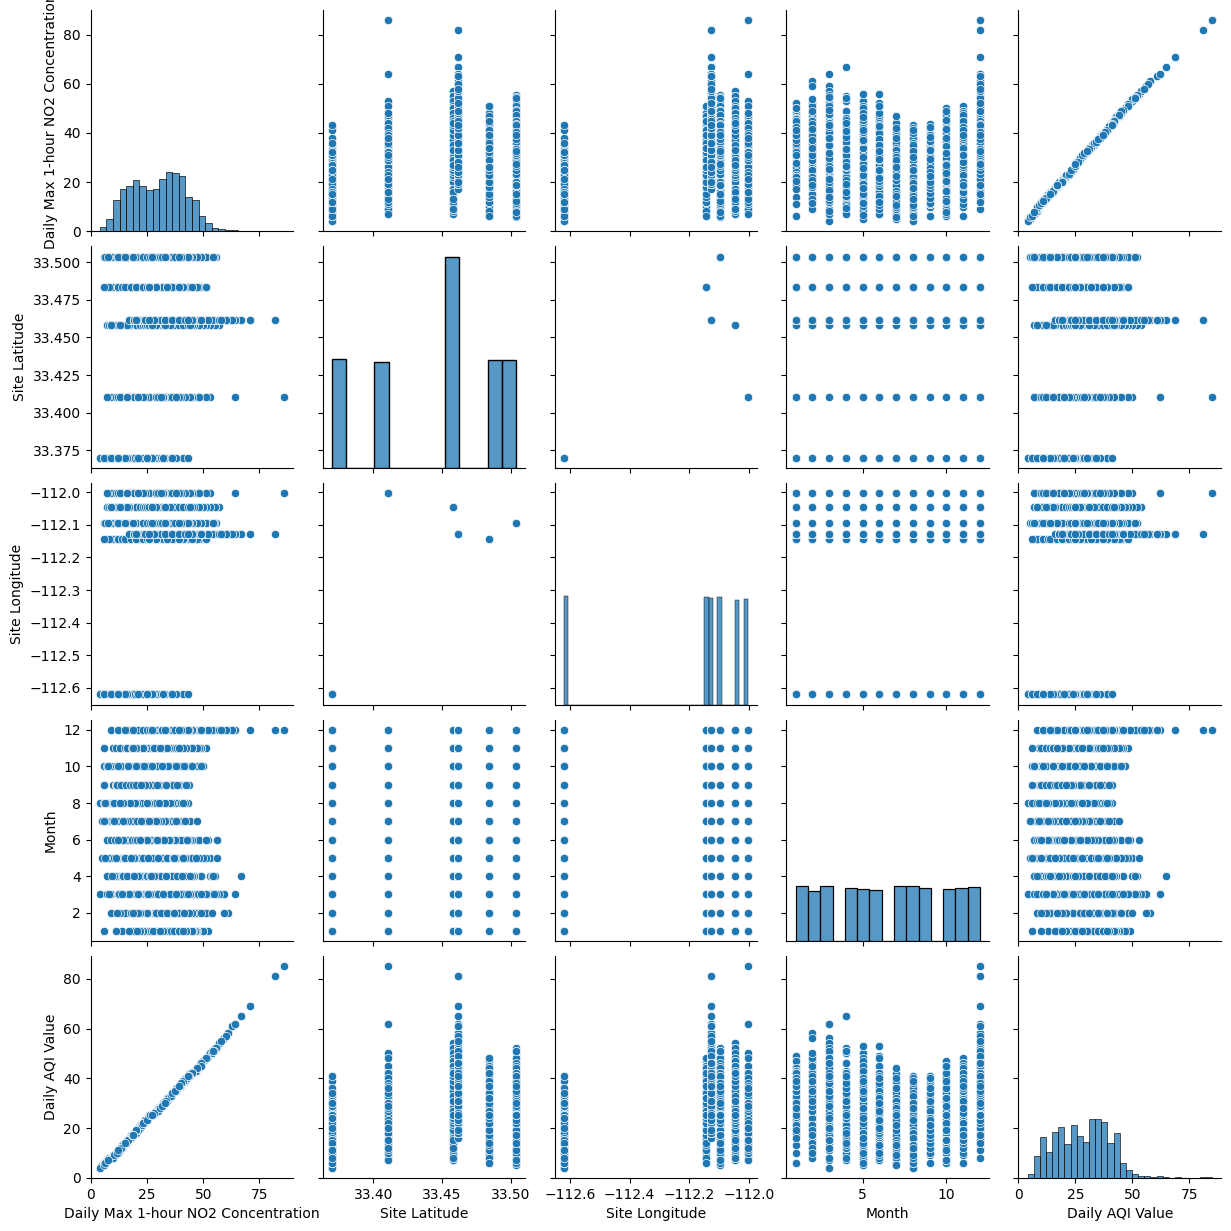

In [35]:
sns.pairplot(df_modelo)
plt.show()

### 5.1. Distribución del AQI diario

Se analiza la distribución de la variable objetivo **Daily AQI Value** mediante un histograma, con el propósito de identificar el intervalo en el que se concentra la mayor cantidad de observaciones.


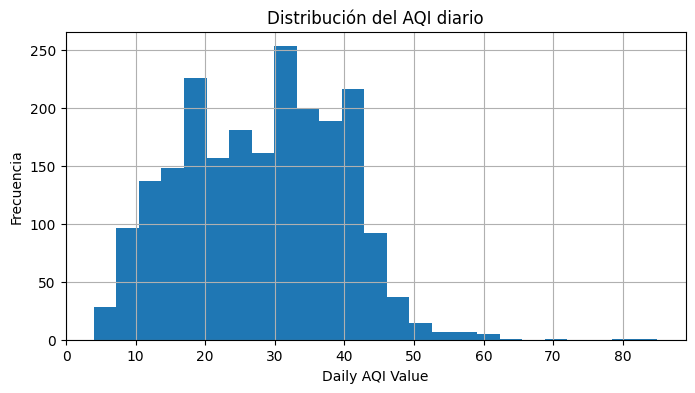

In [36]:
df_modelo["Daily AQI Value"].hist(bins=25, figsize=(8,4))

plt.xlabel("Daily AQI Value")
plt.ylabel("Frecuencia")
plt.title("Distribución del AQI diario")
plt.show()

La mayor parte de los valores de **Daily AQI Value** se concentra aproximadamente entre **15 y 45**. Asimismo, se observan algunos valores elevados con menor frecuencia, lo que produce una ligera asimetría hacia la derecha.


### 5.2. Densidad del AQI diario

Se representa la función de densidad de la variable objetivo para complementar la información obtenida mediante el histograma y observar con mayor claridad la forma de su distribución.


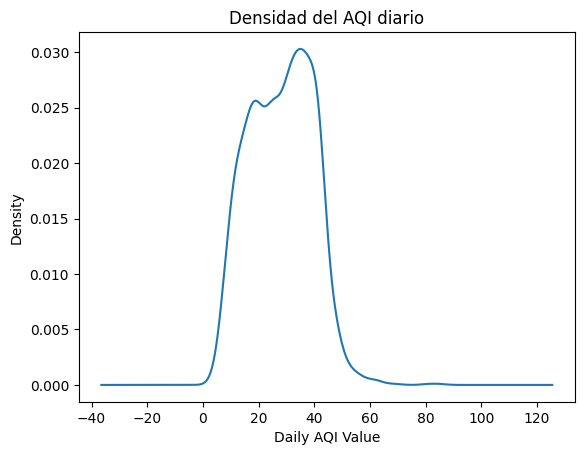

In [37]:
df_modelo["Daily AQI Value"].plot.density()

plt.title("Densidad del AQI diario")
plt.xlabel("Daily AQI Value")
plt.show()

La curva de densidad confirma que la mayor concentración de observaciones se encuentra aproximadamente entre **15 y 45**. También se aprecia una extensión hacia valores superiores, consistente con la asimetría observada previamente.


### 5.3. Matriz de correlación

Se calcula la matriz de correlación de las variables numéricas seleccionadas para evaluar la intensidad y dirección de su relación lineal con **Daily AQI Value**.


In [38]:
numeric_df = df_modelo.select_dtypes(include=[np.number])

numeric_df.corr().round(4)

,Daily Max 1-hour NO2 Concentration,Site Latitude,Site Longitude,Month,Daily AQI Value
Daily Max 1-hour NO2 Concentration,1.0000,0.2931,0.3951,-0.1389,0.9995
Site Latitude,0.2931,1.0000,0.6487,-0.0030,0.2838
Site Longitude,0.3951,0.6487,1.0000,-0.0012,0.3905
Month,-0.1389,-0.0030,-0.0012,1.0000,-0.1375
Daily AQI Value,0.9995,0.2838,0.3905,-0.1375,1.0000


### 5.4. Mapa de calor de correlaciones

El mapa de calor permite representar visualmente los coeficientes de correlación y facilita la comparación entre las variables incluidas en el análisis.


<Axes: >

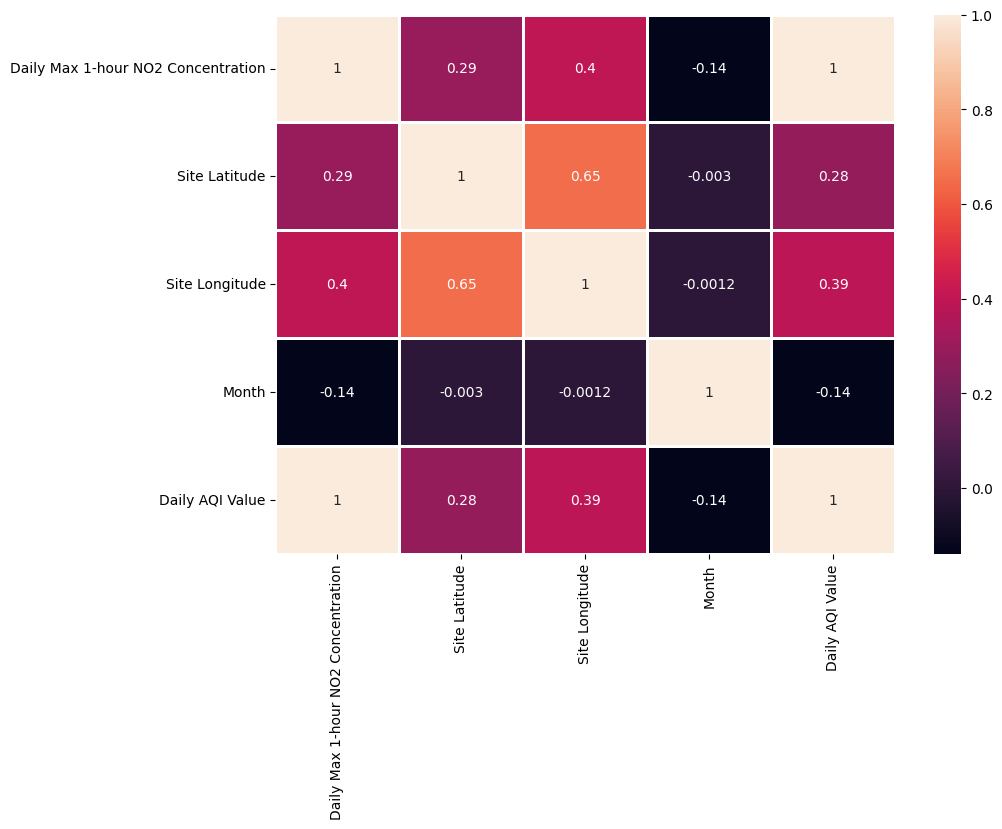

In [39]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    linewidths=2
)

## 6. Definición de características del modelo

Se obtiene la lista de variables que conforman el conjunto utilizado para el modelado. Esta verificación permite confirmar la estructura de los datos antes de separar las variables predictoras y la variable objetivo.


In [40]:
# Lista con los nombres de las columnas seleccionadas
l_column = list(df_modelo.columns)

# Cantidad total de variables
len_feature = len(l_column)

l_column

['Daily Max 1-hour NO2 Concentration',
 'Site Latitude',
 'Site Longitude',
 'Month',
 'Daily AQI Value']

### 6.1. Separación de variables predictoras y variable objetivo

Para la construcción del modelo se definen las siguientes variables:

- **Variables predictoras (X):**
  - Daily Max 1-hour NO2 Concentration
  - Site Latitude
  - Site Longitude
  - Month

- **Variable objetivo (y):**
  - Daily AQI Value

Esta separación permite utilizar las características seleccionadas como entradas del modelo y el AQI diario como valor a estimar.


In [41]:
# Variables predictoras
X = df_modelo[[
    "Daily Max 1-hour NO2 Concentration",
    "Site Latitude",
    "Site Longitude",
    "Month"
]]

# Variable objetivo
y = df_modelo["Daily AQI Value"]

X.head()

,Daily Max 1-hour NO2 Concentration,Site Latitude,Site Longitude,Month
0,17.0,33.48378,-112.14256,1
1,32.0,33.48378,-112.14256,1
2,38.0,33.48378,-112.14256,1
3,38.0,33.48378,-112.14256,1
4,39.0,33.48378,-112.14256,1


In [42]:
y.head()

,Daily AQI Value
0,16
1,30
2,36
3,36
4,37


## 7. División de los datos en entrenamiento y prueba

El conjunto de datos se divide en dos subconjuntos:

- **70 % para entrenamiento:** utilizado para ajustar los parámetros del modelo.
- **30 % para prueba:** utilizado para evaluar su capacidad de predicción.

Se emplea `random_state=123` para garantizar que la división sea reproducible.


In [43]:
from sklearn.model_selection import train_test_split

In [44]:
# Divide los datos en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=123
)
# 70% entrenamiento
# 30% prueba
# random_state permite que la división sea reproducible

## 8. Construcción y entrenamiento del modelo de regresión lineal

Se crea un modelo de **regresión lineal** y se entrena con los datos correspondientes a `x_train` y `y_train`.

Mediante el método `fit()`, el modelo estima los parámetros que describen la relación entre las variables predictoras y **Daily AQI Value**.


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [46]:
# Creando un objeto de Regresión Lineal 'lm'
lm = LinearRegression()

In [47]:
# Entrenamos el modelo con los datos de entrenamiento
lm.fit(x_train, y_train)

LinearRegression()

### 8.1. Intercepto y coeficientes del modelo

Una vez entrenado el modelo, se obtienen el intercepto y los coeficientes asociados a cada variable predictora. Estos valores permiten observar el sentido y la magnitud de la relación estimada entre cada característica y el AQI diario.


In [48]:
# Verificamos la intersección
print("El término de intersección del modelo lineal:", lm.intercept_)

El término de intersección del modelo lineal: 97.86731428345419


In [49]:
# Verificamos los coeficientes del modelo lineal
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [ 0.95365986 -2.68051291  0.07666172  0.00431919]


In [50]:
# Coeficientes asociados a cada variable
cdf = pd.DataFrame(
    data=lm.coef_,
    index=x_train.columns,
    columns=["Coefficients"]
)
cdf

,Coefficients
Daily Max 1-hour NO2 Concentration,0.953660
Site Latitude,-2.680513
Site Longitude,0.076662
Month,0.004319


El coeficiente asociado a **Daily Max 1-hour NO2 Concentration** es aproximadamente **0.954**, por lo que presenta una relación positiva marcada con **Daily AQI Value** dentro del modelo.

Por otro lado, **Site Latitude** presenta un coeficiente negativo, mientras que **Site Longitude** y **Month** muestran coeficientes de menor magnitud.


### 8.2. Error estándar y estadístico t

Se calculan el error estándar y el estadístico *t* de los coeficientes estimados. Estas medidas permiten complementar el análisis de los parámetros obtenidos por el modelo de regresión.


In [51]:
n = x_train.shape[0]  # Cantidad de datos de entrenamiento
k = x_train.shape[1]  # Cantidad de variables predictoras

dfN = n - k  # Grados de libertad

train_pred = lm.predict(x_train)  # Predicciones sobre los datos de entrenamiento

# Calculamos los errores entre los valores predichos y los valores reales
train_error = np.square(train_pred - y_train)
sum_error = np.sum(train_error)

# Calculamos el error estándar de cada coeficiente
se = [0] * len(x_train.columns)
for i in range(k):
    r = (sum_error / dfN)
    r = r / np.sum(
        np.square(
            x_train[list(x_train.columns)[i]]
            - x_train[list(x_train.columns)[i]].mean()
        )
    )

    se[i] = np.sqrt(r)

# Agregamos los errores estándar al DataFrame
cdf["Standard Error"] = se

# Calculamos el estadístico t de cada coeficiente
cdf["t-statistic"] = cdf["Coefficients"] / cdf["Standard Error"]
cdf

,Coefficients,Standard Error,t-statistic
Daily Max 1-hour NO2 Concentration,0.953660,0.000746,1278.922880
Site Latitude,-2.680513,0.197405,-13.578760
Site Longitude,0.076662,0.043057,1.780473
Month,0.004319,0.002596,1.663502


### 8.3. Relación entre las variables predictoras y el AQI

Se generan gráficos de dispersión para observar individualmente la relación entre cada variable predictora y **Daily AQI Value**.


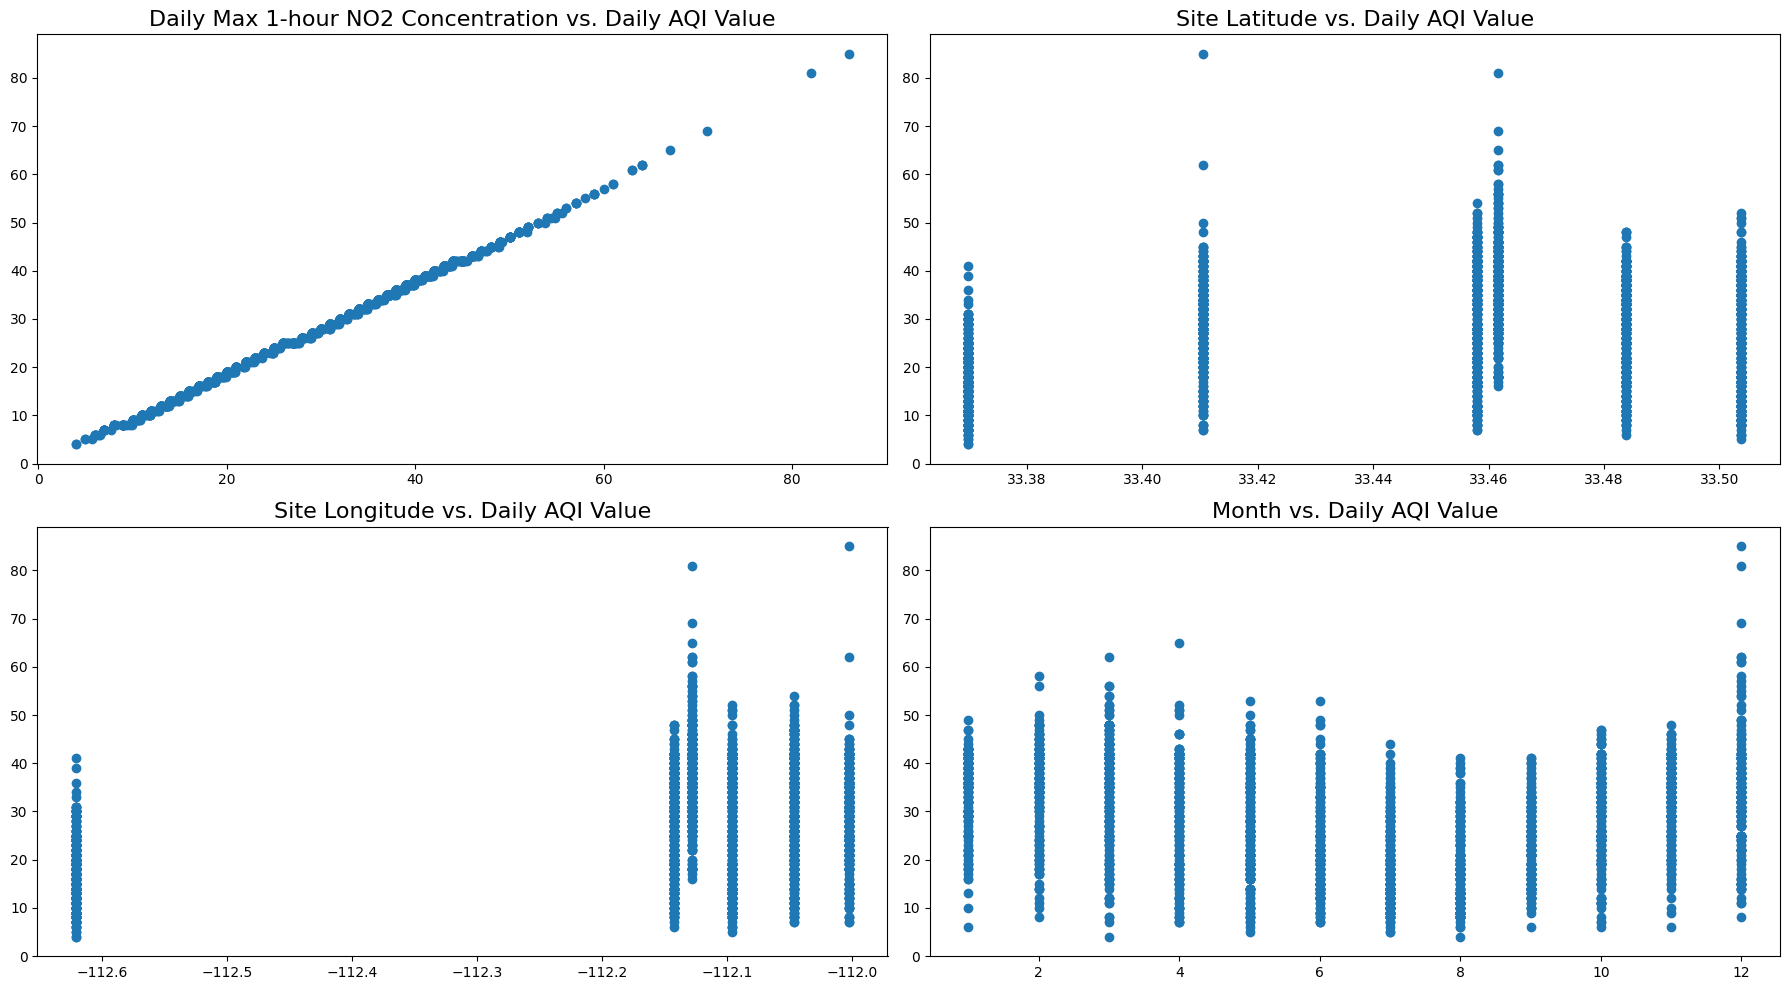

In [52]:
l = list(cdf.index)  # Lista de variables predictoras

from matplotlib import gridspec

# Creamos una figura con cuatro gráficos
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

# NO2 vs Daily AQI Value
ax0 = plt.subplot(gs[0])
ax0.scatter(df_modelo[l[0]], df_modelo["Daily AQI Value"])
ax0.set_title(l[0] + " vs. Daily AQI Value", fontsize=16)

# Site Latitude vs Daily AQI Value
ax1 = plt.subplot(gs[1])
ax1.scatter(df_modelo[l[1]], df_modelo["Daily AQI Value"])
ax1.set_title(l[1] + " vs. Daily AQI Value", fontsize=16)

# Site Longitude vs Daily AQI Value
ax2 = plt.subplot(gs[2])
ax2.scatter(df_modelo[l[2]], df_modelo["Daily AQI Value"])
ax2.set_title(l[2] + " vs. Daily AQI Value", fontsize=16)

# Month vs Daily AQI Value
ax3 = plt.subplot(gs[3])
ax3.scatter(df_modelo[l[3]], df_modelo["Daily AQI Value"])
ax3.set_title(l[3] + " vs. Daily AQI Value", fontsize=16)

plt.tight_layout()
plt.show()

## 9. Evaluación del modelo

### 9.1. Generación de predicciones

El modelo entrenado se utiliza para estimar los valores de **Daily AQI Value** correspondientes al conjunto de prueba `x_test`.

Las predicciones obtenidas serán comparadas con los valores reales para evaluar el desempeño del modelo.


In [53]:
# Realizamos las predicciones con los datos de prueba
predictions = lm.predict(x_test)

# Verificamos el tipo de dato de las predicciones
print("Tipo del objeto predicho:", type(predictions))

# Verificamos la cantidad de predicciones obtenidas
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho: (648,)


### 9.2. Comparación entre valores reales y predichos

Se construye un gráfico de dispersión entre los valores reales y los valores predichos del AQI. Una mayor proximidad de los puntos a una relación lineal indica una mejor correspondencia entre las predicciones y los datos observados.


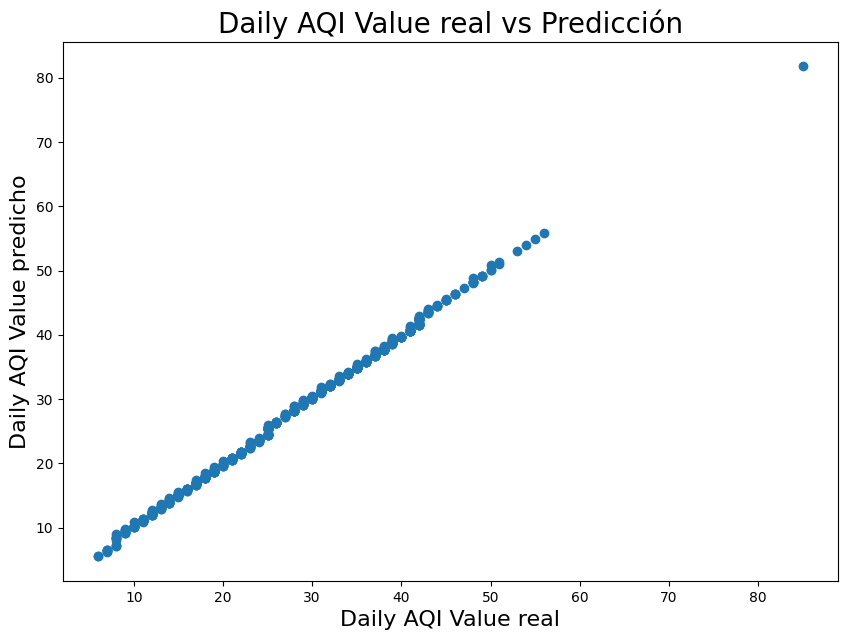

In [54]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(10,7))

# Título y nombres de los ejes
plt.title("Daily AQI Value real vs Predicción", fontsize=20)
plt.xlabel("Daily AQI Value real", fontsize=16)
plt.ylabel("Daily AQI Value predicho", fontsize=16)

# Gráfico de dispersión entre valores reales y predichos
plt.scatter(x=y_test, y=predictions)

plt.show()

Se observa una alta correspondencia visual entre los valores reales y los valores predichos, lo que evidencia un buen ajuste del modelo sobre el conjunto de prueba.


### 9.3. Análisis de residuos

Los residuos representan la diferencia entre los valores reales y los valores predichos por el modelo. Su distribución se analiza mediante un histograma y una curva de densidad para evaluar el comportamiento de los errores.


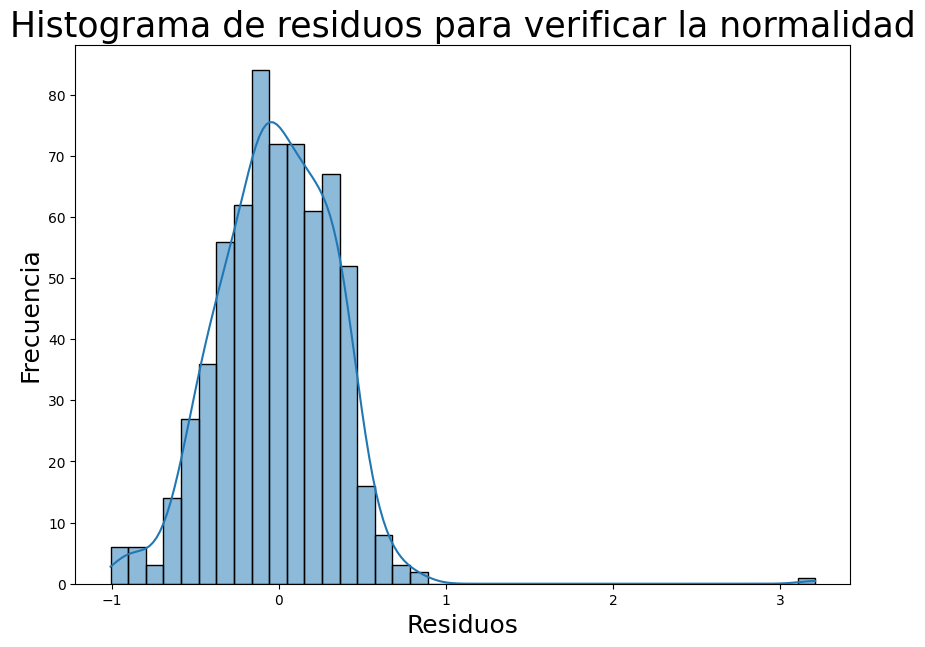

In [55]:
# Calculamos los residuos
residuos = y_test - predictions

# Configuramos el tamaño del gráfico
plt.figure(figsize=(10,7))

# Título y nombres de los ejes
plt.title("Histograma de residuos para verificar la normalidad", fontsize=25)
plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Frecuencia", fontsize=18)

# Distribución de los residuos
sns.histplot(residuos, kde=True)

plt.show()

Los residuos se concentran principalmente alrededor de cero. Este comportamiento permite examinar si los errores del modelo se encuentran centrados y si presentan una distribución razonablemente estable.


### 9.4. Homocedasticidad de los residuos

Se comparan los valores predichos con sus respectivos residuos. Este gráfico permite evaluar visualmente si la dispersión de los errores se mantiene aproximadamente constante a lo largo del rango de predicciones.


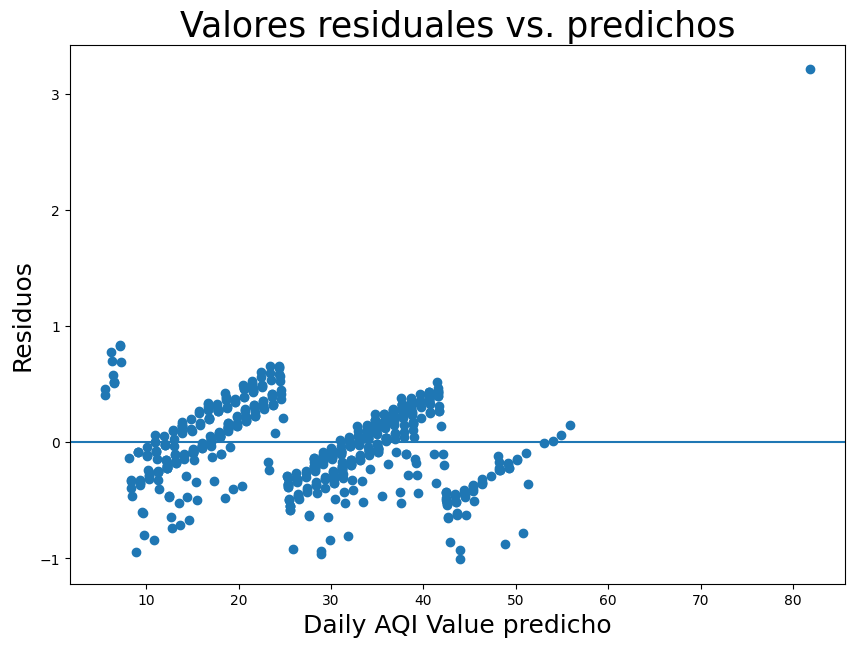

In [56]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(10,7))

# Título y nombres de los ejes
plt.title("Valores residuales vs. predichos", fontsize=25)
plt.xlabel("Daily AQI Value predicho", fontsize=18)
plt.ylabel("Residuos", fontsize=18)

# Comparación entre valores predichos y residuos
plt.scatter(predictions, residuos)

# Línea de referencia en cero
plt.axhline(y=0)

plt.show()

### 9.5. Error cuadrático medio (MSE)

Se calcula el **Mean Squared Error (MSE)** como medida del error promedio de predicción del modelo. Un valor menor indica una menor diferencia cuadrática entre los valores reales y los valores estimados.


In [66]:
print(
    "Mean square error (MSE):",
    metrics.mean_squared_error(y_test, predictions)
)

Mean square error (MSE): 0.12318200790372916


## 10. Resumen estadístico mediante mínimos cuadrados ordinarios

Como complemento al modelo de regresión lineal, se utiliza **Ordinary Least Squares (OLS)** para obtener un resumen estadístico de los parámetros estimados.

Este análisis permite observar indicadores como el coeficiente de determinación **R²**, los errores estándar, los estadísticos *t* y los valores *p* asociados a las variables del modelo.


In [67]:
import statsmodels.api as sm

In [68]:
Xs = sm.add_constant(X)

stat_model = sm.OLS(y, Xs)

stat_result = stat_model.fit()

print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:        Daily AQI Value   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 5.750e+05
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:59:27   Log-Likelihood:                -779.88
No. Observations:                2157   AIC:                             1570.
Df Residuals:                    2152   BIC:                             1598.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

## 11. Conclusiones

El análisis se realizó sobre **2 157 registros diarios** correspondientes al año 2022. El modelo de regresión lineal presentó un **MSE de aproximadamente 0.123**, lo que evidencia una diferencia reducida entre los valores reales y los valores predichos en el conjunto de prueba.

El resumen estadístico mediante OLS obtuvo un **R² de 0.999**, indicando que el modelo explica una proporción muy elevada de la variabilidad observada en **Daily AQI Value** para el conjunto de variables analizado.

Entre las características incluidas, **Daily Max 1-hour NO2 Concentration** presentó el coeficiente positivo más destacado. La latitud mostró una relación negativa, mientras que la longitud y el mes presentaron efectos de menor magnitud.

En conjunto, los resultados muestran que el modelo construido presenta un ajuste elevado para los datos considerados en este análisis.
